#  Medical Insurance Cost Prediction Using Machine Learning

## Capstone Project

### Team: CareCast



### Project Overview

Healthcare insurance companies rely on predictive analytics to estimate the medical expenses of customers. Accurate predictions enable insurers to develop fair premium pricing strategies, improve financial planning, and identify high-risk individuals.

In this project, we perform Exploratory Data Analysis (EDA) to investigate the factors that influence healthcare insurance charges and develop machine learning regression models capable of accurately predicting individual medical insurance costs.

The project follows the complete data science workflow, including data understanding, data preprocessing, exploratory analysis, model development, evaluation, and business recommendations.

# Table of Contents

1. Business Understanding
2. Dataset Description
3. Data Loading
4. Data Understanding
5. Exploratory Data Analysis (EDA)
6. Feature Engineering & Data Preprocessing
7. Model Development
8. Model Evaluation & Interpretation
9. Business Recommendations
10. Project Conclusion
11. Limitations
12. Future Work

# 1. Business Understanding

## Problem Statement

Healthcare expenses vary significantly among individuals due to differences in age, body mass index (BMI), smoking habits, family size, sex, and geographical region. Insurance providers require reliable prediction models to estimate expected medical charges for customers.

The objective of this project is to build a machine learning regression model capable of accurately predicting individual medical insurance charges using demographic and health-related information.



## Business Objectives

The main objectives of this project are to:

- Understand the factors influencing healthcare insurance charges.
- Perform Exploratory Data Analysis (EDA) to uncover meaningful insights.
- Prepare the dataset for machine learning.
- Develop and compare multiple regression models.
- Identify the most accurate prediction model.
- Interpret the factors with the greatest impact on insurance costs.
- Provide recommendations that can support insurance pricing and risk assessment.

# 2. Dataset Description

The dataset contains demographic and health-related information collected from insurance beneficiaries.

### Features

| Feature | Description |
|---------|-------------|
| age | Age of the primary beneficiary |
| sex | Gender of the beneficiary |
| bmi | Body Mass Index |
| children | Number of dependents covered by insurance |
| smoker | Smoking status |
| region | Residential region in the United States |
| charges | Individual medical insurance charges (Target Variable) |

The target variable is **charges**, which represents the total medical insurance expenses incurred by each individual.

In [67]:

# Medical Insurance Cost Prediction
# Import all required libraries

# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import (train_test_split, cross_val_score, GridSearchCV)

from sklearn.preprocessing import (LabelEncoder, StandardScaler)

from sklearn.linear_model import LinearRegression

from sklearn.tree import DecisionTreeRegressor

from sklearn.ensemble import (RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor)

# Model evaluation metrics
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score)

# Save trained models
import joblib

# Ignore unnecessary warnings
import warnings
warnings.filterwarnings("ignore")

# Improve visualization appearance
plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

print("Libraries imported successfully.")

Libraries imported successfully.


In [68]:
# Load the insurance dataset


df = pd.read_csv(r"C:\Users\User\Downloads\insurance.csv")

# Display the first five rows
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


# 3. Data Loading

The dataset has been successfully loaded into a pandas DataFrame.

The next step is to inspect its structure, identify data types, detect missing values, and gain an initial understanding of the available features before proceeding with data cleaning and exploratory data analysis.

# 4. Data Understanding

Before performing any data preprocessing or model development, it is important to understand the structure and quality of the dataset.

In this section, we examine:

- Dataset dimensions
- Data types
- Missing values
- Duplicate records
- Summary statistics
- Unique values for categorical variables

These checks help identify any data quality issues that may affect model performance.

In [69]:
# Display the number of rows and columns

print(f"Number of Rows: {df.shape[0]}")
print(f"Number of Columns: {df.shape[1]}")

Number of Rows: 1338
Number of Columns: 7


### Observation

The dataset contains **1,338 observations** and **7 variables**.

The number of observations is sufficient for building and evaluating regression models while maintaining computational efficiency.

In [70]:
# Display information about the dataset

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


### Observation

The dataset contains both **numerical** and **categorical** variables.

Numerical variables:
- Age
- BMI
- Children
- Charges

Categorical variables:
- Sex
- Smoker
- Region

The target variable (**charges**) is numerical, making this a supervised regression problem.

In [71]:
# Display the data type of each feature

df.dtypes

age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object

In [72]:
# Check for missing values

missing_values = df.isnull().sum()

missing_values

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

### Observation

No missing values were found in the dataset.

This indicates that no imputation techniques are required before model development.

In [73]:
# Check for duplicate observations

duplicates = df.duplicated().sum()

print(f"Duplicate Records: {duplicates}")

Duplicate Records: 1


In [74]:
# Remove duplicate records (if any)

df = df.drop_duplicates()

print("New Dataset Shape:", df.shape)

New Dataset Shape: (1337, 7)


### Observation

Duplicate records, if present, were removed to prevent the model from learning repeated information that could bias the results.

Removing duplicates improves the overall quality and reliability of the dataset.

In [75]:
# Generate descriptive statistics

df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,1337.0,39.222139,14.044333,18.0000,27.000,39.0000,51.00000,64.00000
bmi,1337.0,30.663452,6.100468,15.9600,26.290,30.4000,34.70000,53.13000
children,1337.0,1.095737,1.205571,0.0000,0.000,1.0000,2.00000,5.00000
charges,1337.0,13279.121487,12110.359656,1121.8739,4746.344,9386.1613,16657.71745,63770.42801


### Observation

The descriptive statistics provide an overview of the numerical variables.

Some key observations include:

- Age ranges from young adults to older individuals.
- BMI values vary considerably, indicating differences in body weight.
- Medical insurance charges exhibit a wide range, suggesting substantial variability in healthcare expenses.
- The target variable (charges) appears highly dispersed, indicating the possible presence of outliers.

In [76]:
# Summary statistics for categorical variables

df.describe(include="object").T

,count,unique,top,freq
sex,1337,2,male,675
smoker,1337,2,no,1063
region,1337,4,southeast,364


In [77]:
# Display unique values for categorical variables

categorical_columns = df.select_dtypes(include="object").columns

for column in categorical_columns:
    print(f"\n{column.upper()}")
    print(df[column].value_counts())


SEX
sex
male      675
female    662
Name: count, dtype: int64

SMOKER
smoker
no     1063
yes     274
Name: count, dtype: int64

REGION
region
southeast    364
southwest    325
northwest    324
northeast    324
Name: count, dtype: int64


### Observation

The categorical variables contain a limited number of distinct categories.

- **Sex** consists of male and female beneficiaries.
- **Smoker** indicates whether an individual smokes.
- **Region** categorizes beneficiaries into four geographical locations.

These variables will require numerical encoding before they can be used in machine learning models.

In [78]:
# Identify numerical and categorical columns

numerical_columns = df.select_dtypes(include=["int64", "float64"]).columns

categorical_columns = df.select_dtypes(include=["object"]).columns

print("Numerical Features")
print(numerical_columns.tolist())

print("\nCategorical Features")
print(categorical_columns.tolist())

Numerical Features
['age', 'bmi', 'children', 'charges']

Categorical Features
['sex', 'smoker', 'region']


# Data Understanding Summary

The dataset inspection revealed that:

- The dataset is complete with no missing values.
- Duplicate records have been removed.
- The dataset contains both numerical and categorical variables.
- The target variable (**charges**) is continuous, confirming that this is a regression problem.
- Categorical variables will require encoding before model training.

With the dataset successfully inspected and cleaned, the next step is to perform Exploratory Data Analysis (EDA) to identify patterns, relationships, and potential predictors of medical insurance charges.

# 5. Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) is performed to understand the distribution of variables, identify patterns, detect outliers, and examine relationships between features and healthcare insurance charges.

The insights obtained from EDA will guide feature engineering and help explain the performance of the machine learning models.

## 5.1 Distribution of Numerical Variables

We first examine the distribution of the numerical variables to understand their spread, identify skewness, and detect potential outliers.

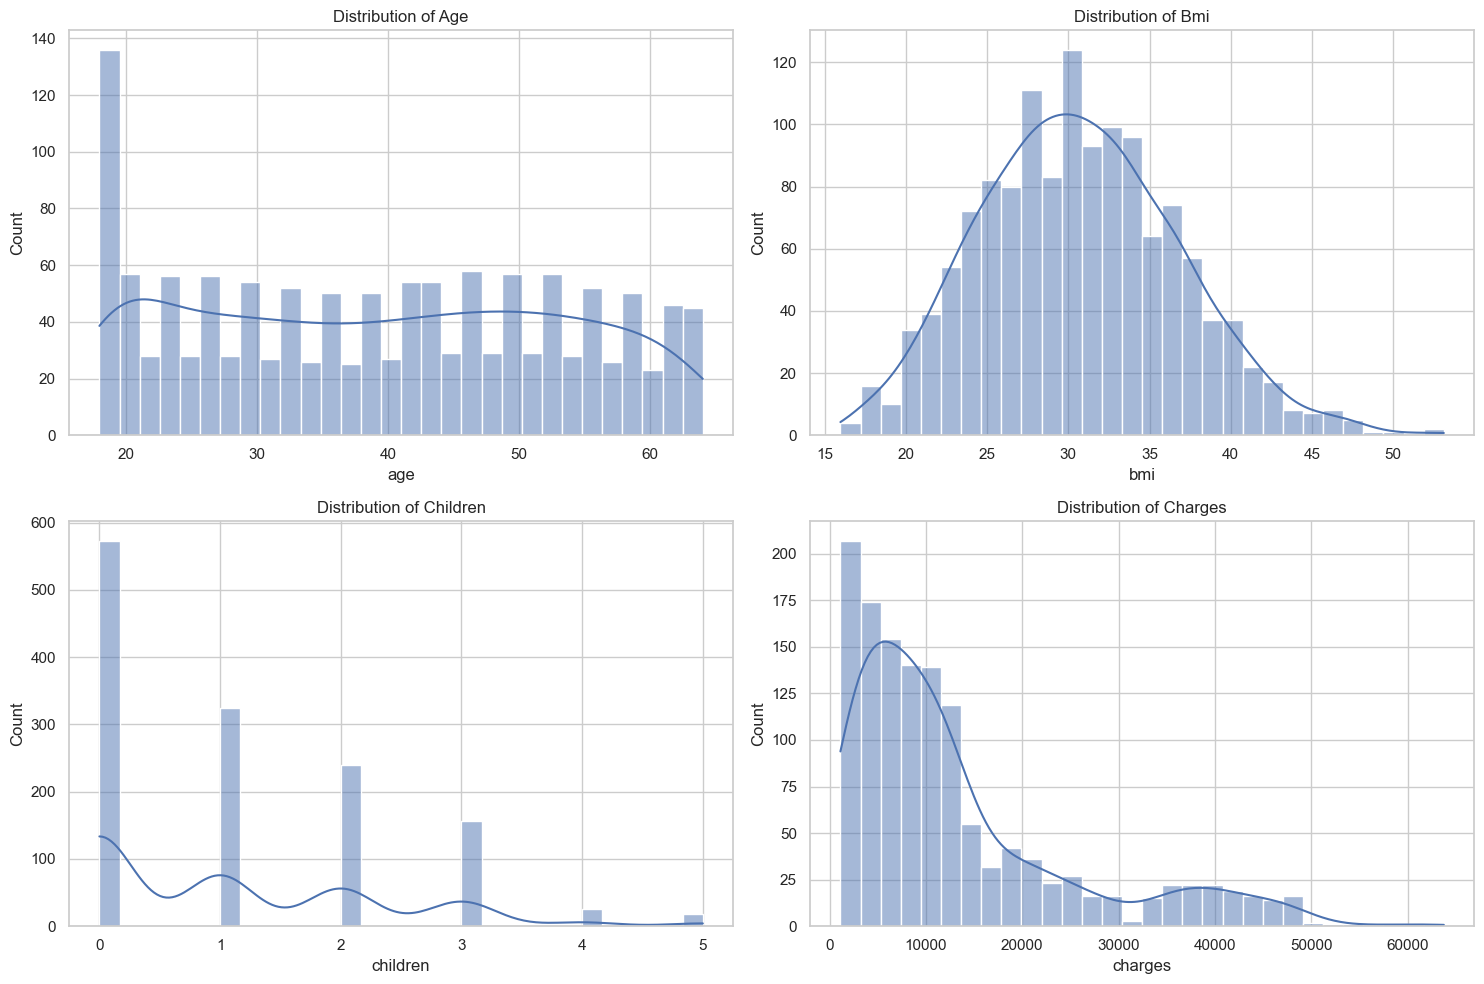

In [79]:
# Distribution of Numerical Variables

numerical_features = ["age", "bmi", "children", "charges"]

plt.figure(figsize=(15,10))

for i, column in enumerate(numerical_features, 1):
    plt.subplot(2,2,i)

    sns.histplot(
        data=df,
        x=column,
        kde=True,
        bins=30
    )

    plt.title(f"Distribution of {column.capitalize()}")

plt.tight_layout()
plt.show()

### Observations

- **Age** is fairly evenly distributed across different age groups.
- **BMI** follows an approximately normal distribution, although a few individuals have unusually high BMI values.
- **Children** is positively skewed, with most beneficiaries having fewer dependents.
- **Charges** are heavily right-skewed, indicating that a relatively small number of individuals incur very high medical expenses.

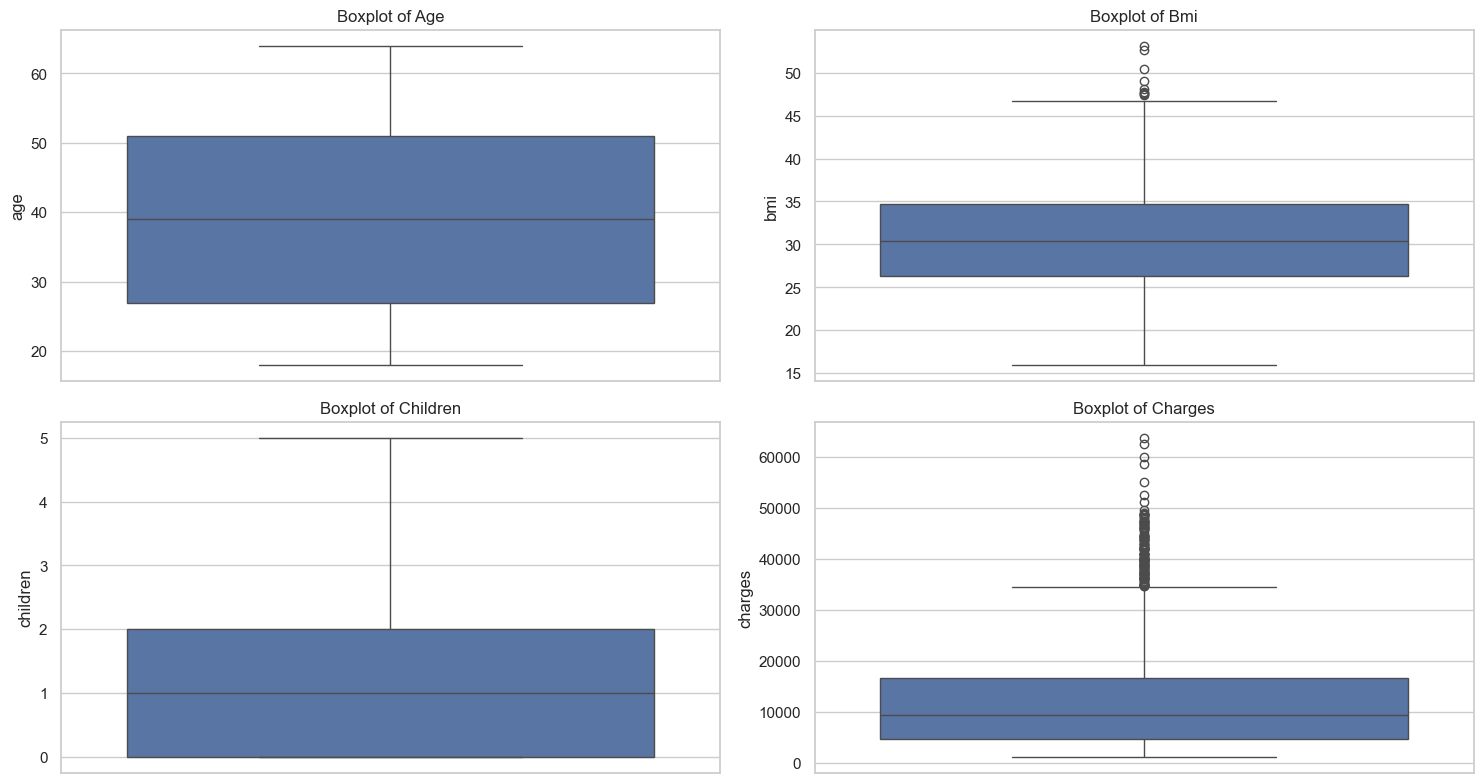

In [80]:
# Detect Outliers

plt.figure(figsize=(15,8))

for i, column in enumerate(numerical_features,1):

    plt.subplot(2,2,i)

    sns.boxplot(y=df[column])

    plt.title(f"Boxplot of {column.capitalize()}")

plt.tight_layout()

plt.show()

### Observations

The boxplots reveal the presence of outliers, particularly in:

- BMI
- Charges

The high values observed in the **charges** variable are expected in healthcare datasets because a small proportion of patients typically require significantly more medical care than the general population.

These values will be retained because they represent genuine observations rather than data entry errors.

## 5.2 Distribution of Categorical Variables

Next, we examine the frequency distribution of categorical variables to understand the composition of the dataset.

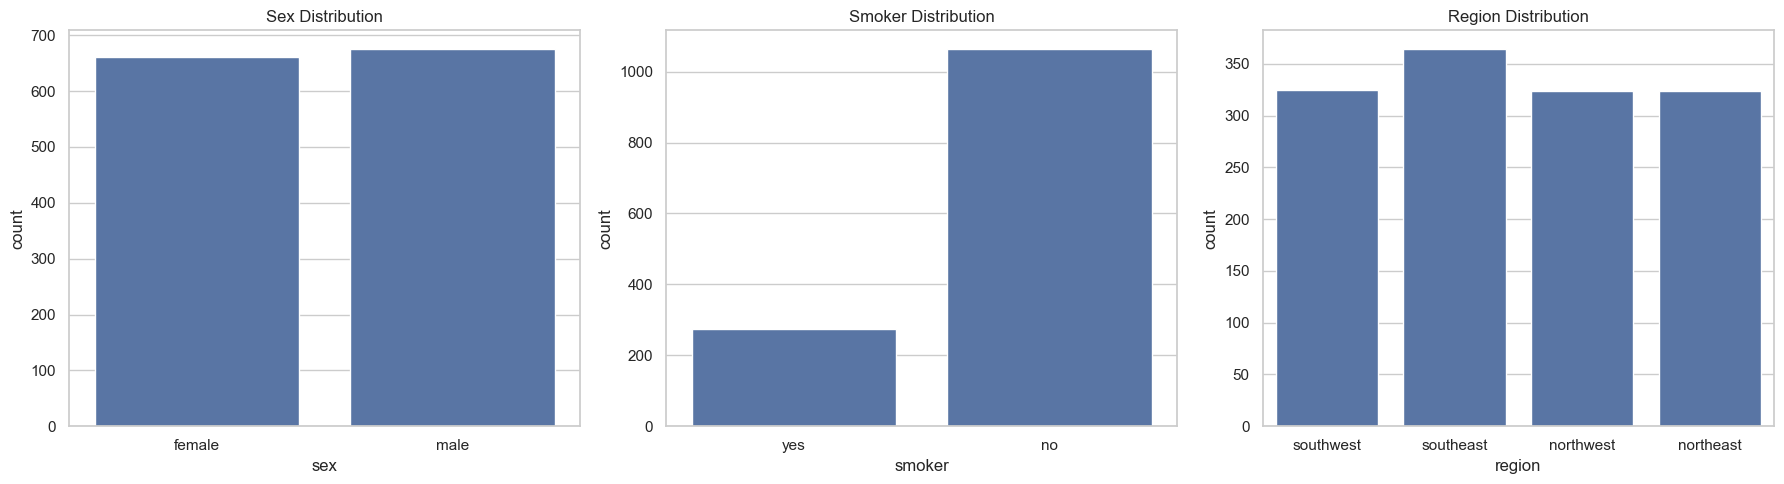

In [81]:
# Countplots of Categorical Variables

categorical_features = ["sex","smoker","region"]

plt.figure(figsize=(18,5))

for i, column in enumerate(categorical_features,1):

    plt.subplot(1,3,i)

    sns.countplot(
        data=df,
        x=column
    )

    plt.title(f"{column.capitalize()} Distribution")

plt.tight_layout()

plt.show()

### Observations

- The dataset contains a relatively balanced number of male and female beneficiaries.
- Most individuals are non-smokers.
- Beneficiaries are fairly evenly distributed across the four geographical regions.

The balanced distribution reduces the likelihood of severe class imbalance in the categorical features.

## 5.3 Relationship Between Features and Insurance Charges

The purpose of this section is to identify which variables are associated with higher healthcare insurance charges.

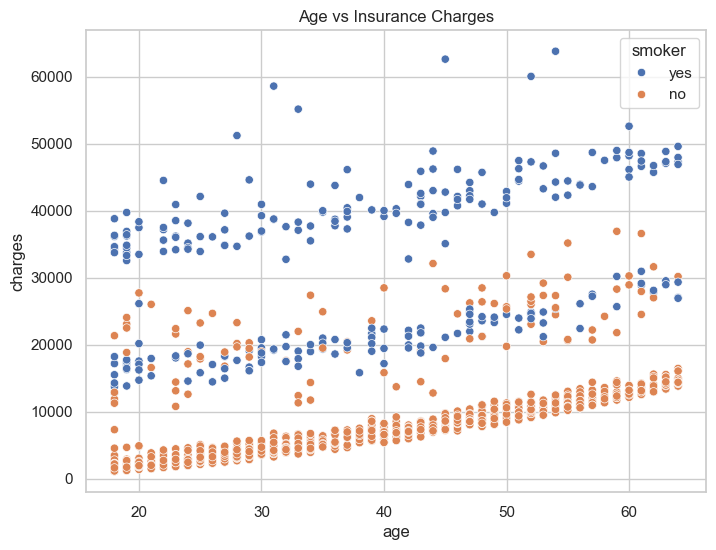

In [82]:
# Age vs Charges

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="age",
    y="charges",
    hue="smoker"
)

plt.title("Age vs Insurance Charges")

plt.show()

### Observation

Insurance charges generally increase with age.

Smokers consistently incur substantially higher medical expenses than non-smokers across nearly all age groups, indicating that smoking is likely to be a strong predictor of insurance charges.

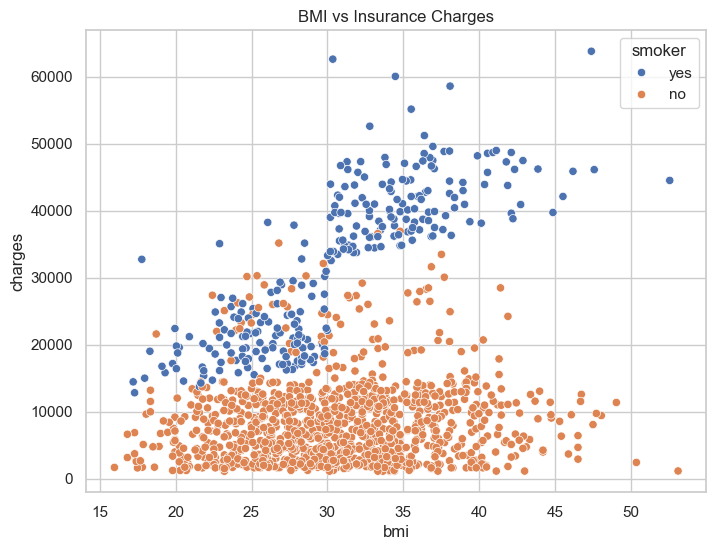

In [84]:
# BMI vs Charges

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="bmi",
    y="charges",
    hue="smoker"
)

plt.title("BMI vs Insurance Charges")

plt.show()

### Observation

BMI shows a moderate positive relationship with insurance charges.

Individuals with higher BMI who also smoke tend to incur significantly higher healthcare costs than non-smokers.

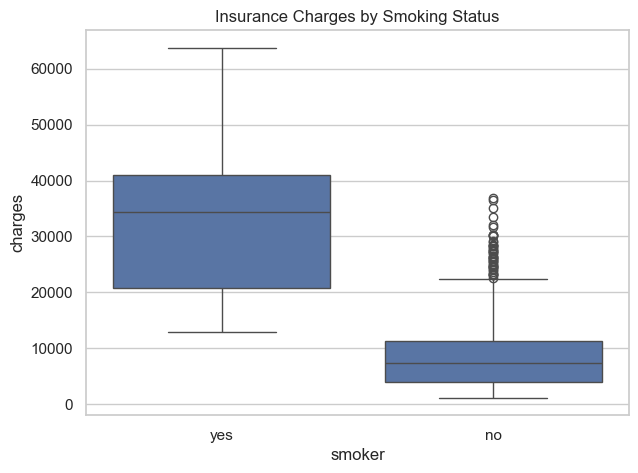

In [85]:

# Smoking Status vs Charges

plt.figure(figsize=(7,5))

sns.boxplot(
    data=df,
    x="smoker",
    y="charges"
)

plt.title("Insurance Charges by Smoking Status")

plt.show()

### Observation

Smoking status has the strongest visible relationship with insurance charges.

Smokers have substantially higher median and maximum healthcare expenses than non-smokers, highlighting smoking as a major risk factor.

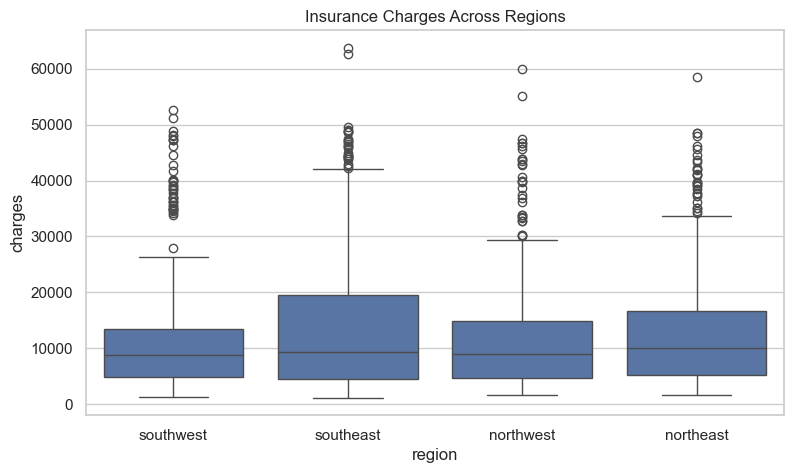

In [86]:
# Region vs Charges

plt.figure(figsize=(9,5))

sns.boxplot(
    data=df,
    x="region",
    y="charges"
)

plt.title("Insurance Charges Across Regions")

plt.show()

### Observation

Healthcare charges appear relatively similar across the four regions.

This suggests that geographical location has a weaker influence on insurance charges compared to variables such as smoking status, age, and BMI.

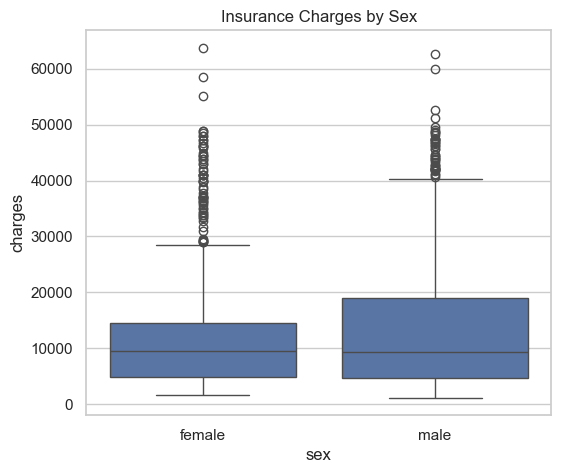

In [87]:
# Sex vs Charges

plt.figure(figsize=(6,5))

sns.boxplot(
    data=df,
    x="sex",
    y="charges"
)

plt.title("Insurance Charges by Sex")

plt.show()

### Observation

Male and female beneficiaries exhibit comparable insurance charges.

Sex does not appear to be a strong determinant of healthcare expenses within this dataset.

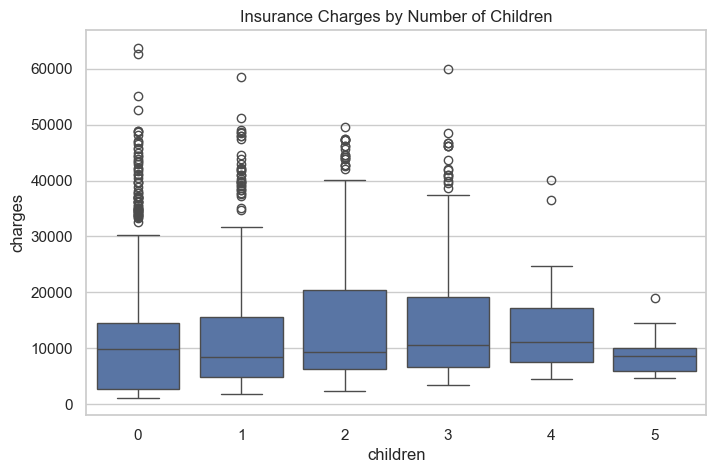

In [88]:
# Children vs Charges

plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="children",
    y="charges"
)

plt.title("Insurance Charges by Number of Children")

plt.show()

### Observation

The number of children covered by insurance has only a modest effect on healthcare charges.

Although some variation exists, no strong trend is observed compared to the influence of smoking status or age.

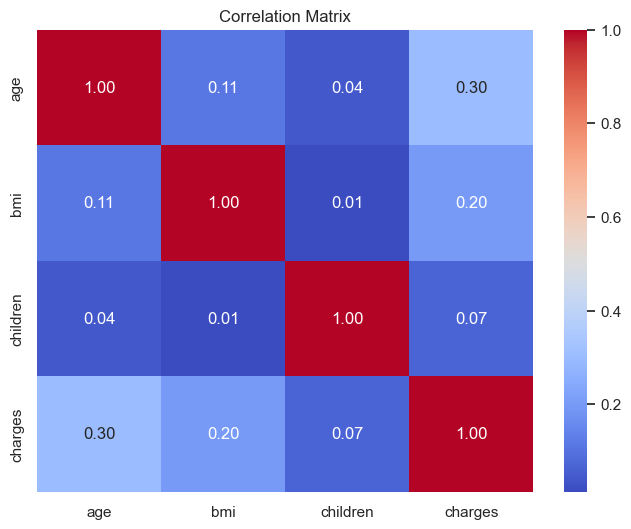

In [89]:
# Correlation Analysis

numeric_df = df.select_dtypes(include=["number"])

plt.figure(figsize=(8,6))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

### Correlation Analysis

The correlation matrix indicates that:

- **Age** has a positive correlation with insurance charges.
- **BMI** exhibits a moderate positive correlation with healthcare expenses.
- **Children** has a relatively weak correlation with charges.

Since the categorical variables have not yet been encoded at this stage, **smoking status is not included in the heatmap**. However, previous visualizations clearly indicate that smoking is one of the strongest predictors of healthcare insurance charges.

# EDA Summary

Key findings from the exploratory analysis include:

- Medical insurance charges are highly right-skewed.
- Smoking status is the strongest observable predictor of healthcare expenses.
- Older individuals generally incur higher insurance charges.
- Higher BMI is associated with increased medical costs, particularly among smokers.
- Region and sex appear to have relatively little influence on insurance charges.
- The dataset contains genuine high-cost outliers, which are expected in healthcare expenditure data and will be retained for model development.

These insights provide a strong foundation for feature engineering and the development of predictive machine learning models.

# 6. Feature Engineering and Data Preprocessing

Machine learning algorithms require numerical input features. Therefore, categorical variables must be transformed into numerical representations before model training.

In this section, we will:

- Encode categorical variables.
- Separate features and the target variable.
- Split the dataset into training and testing sets.
- Standardize numerical features to improve model performance.

In [90]:
# Encode Binary Categorical Variables

# Create a LabelEncoder object
label_encoder = LabelEncoder()

# Encode binary categorical variables
df["sex"] = label_encoder.fit_transform(df["sex"])
df["smoker"] = label_encoder.fit_transform(df["smoker"])

# Display the first five rows
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,0,27.900,0,1,southwest,16884.92400
1,18,1,33.770,1,0,southeast,1725.55230
2,28,1,33.000,3,0,southeast,4449.46200
3,33,1,22.705,0,0,northwest,21984.47061
4,32,1,28.880,0,0,northwest,3866.85520


### Why Label Encoding?

The variables **sex** and **smoker** contain only two categories each.

Binary variables can be safely encoded as 0 and 1 without introducing any misleading ordinal relationship.

For example:

- Sex:
  - Female = 0
  - Male = 1

- Smoker:
  - No = 0
  - Yes = 1

In [91]:
# One-Hot Encode Region

# Convert the region variable into dummy variables
df = pd.get_dummies(
    df,
    columns=["region"],
    drop_first=True
)

# Display the first five rows
df.head()

,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest
0,19,0,27.900,0,1,16884.92400,False,False,True
1,18,1,33.770,1,0,1725.55230,False,True,False
2,28,1,33.000,3,0,4449.46200,False,True,False
3,33,1,22.705,0,0,21984.47061,True,False,False
4,32,1,28.880,0,0,3866.85520,True,False,False


### Why One-Hot Encoding?

Unlike binary variables, **region** contains four categories.

Using Label Encoding would incorrectly imply an ordinal relationship between regions.

One-Hot Encoding creates separate binary columns for each region, allowing the model to treat each region independently.

In [92]:
# Separate Features and Target Variable

# Predictor variables
X = df.drop("charges", axis=1)

# Target variable
y = df["charges"]

print("Feature Matrix Shape:", X.shape)
print("Target Vector Shape:", y.shape)

Feature Matrix Shape: (1337, 8)
Target Vector Shape: (1337,)


### Feature Matrix and Target Variable

The dataset has been divided into:

- **X (Features):** Independent variables used for prediction.
- **y (Target):** Medical insurance charges to be predicted.

In [93]:
# Split the Dataset

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Set:", X_train.shape)
print("Testing Set:", X_test.shape)

Training Set: (1069, 8)
Testing Set: (268, 8)


### Why Train-Test Split?

The dataset is divided into:

- **80% Training Data** for model learning.
- **20% Testing Data** for evaluating model performance on unseen data.

Using unseen data provides a realistic assessment of how well the model generalizes to new observations.

In [94]:
# Standardize Numerical Features

# Initialize the scaler
scaler = StandardScaler()

# Scale the training data
X_train_scaled = scaler.fit_transform(X_train)

# Scale the testing data
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed successfully.")

Feature scaling completed successfully.


### Why Standardization?

Many machine learning algorithms perform better when numerical features are on a similar scale.

Standardization transforms the features so that:

- Mean = 0
- Standard Deviation = 1

The scaler is fitted only on the training data to prevent data leakage. The same transformation is then applied to the test data.

In [95]:
# Preview the Scaled Training Data

scaled_features = pd.DataFrame(
    X_train_scaled,
    columns=X.columns
)

scaled_features.head()

,age,sex,bmi,children,smoker,region_northwest,region_southeast,region_southwest
0,-1.157680,0.971409,-0.996928,-0.907908,-0.500292,-0.572669,-0.605812,-0.57411
1,-1.300619,0.971409,-0.792762,0.766904,-0.500292,-0.572669,-0.605812,-0.57411
2,0.914926,-1.029432,1.154664,0.766904,-0.500292,1.746208,-0.605812,-0.57411
3,1.701087,0.971409,1.806837,-0.907908,-0.500292,-0.572669,1.650678,-0.57411
4,0.557580,-1.029432,-0.651417,0.766904,-0.500292,-0.572669,-0.605812,-0.57411


# Preprocessing Summary

The dataset has now been fully prepared for machine learning.

The preprocessing steps completed include:

- Binary categorical variables encoded using Label Encoding.
- Region encoded using One-Hot Encoding.
- Features and target variable separated.
- Dataset split into training and testing sets.
- Numerical features standardized using StandardScaler.

The processed dataset is now ready for regression model development.

In [96]:
# Save the fitted StandardScaler


joblib.dump(scaler, "standard_scaler.pkl")

print("StandardScaler saved successfully.")

StandardScaler saved successfully.


# 7. Model Development

The objective of this stage is to develop multiple regression models capable of predicting healthcare insurance charges.

Rather than relying on a single algorithm, several regression models are trained and evaluated. Comparing different models helps identify the algorithm that provides the most accurate predictions for this dataset.

The following regression models will be implemented:

- Linear Regression
- Decision Tree Regressor
- Random Forest Regressor
- Gradient Boosting Regressor
- Extra Trees Regressor

These models were selected because they represent both simple and advanced machine learning techniques, allowing us to compare linear and ensemble-based approaches for predicting healthcare insurance charges.

In [97]:
# Initialize Regression Models

models = {

    "Linear Regression": LinearRegression(),

    "Decision Tree": DecisionTreeRegressor(
        random_state=42
    ),

    "Random Forest": RandomForestRegressor(
        random_state=42
    ),

    "Gradient Boosting": GradientBoostingRegressor(
        random_state=42
    ),

    "Extra Trees": ExtraTreesRegressor(
        random_state=42
    )
}

print(f"{len(models)} models initialized successfully.")

5 models initialized successfully.


### Why These Models?

Five regression algorithms are implemented to compare different learning approaches and identify the most accurate model for predicting healthcare insurance charges.

- **Linear Regression** serves as the baseline model and assumes a linear relationship between the predictors and the target variable.

- **Decision Tree Regressor** captures complex non-linear relationships by recursively splitting the data into decision rules.

- **Random Forest Regressor** combines multiple decision trees to improve prediction accuracy while reducing overfitting.

- **Gradient Boosting Regressor** builds trees sequentially, with each new tree correcting the errors of the previous one. It is widely recognized for its strong predictive performance on structured datasets.

- **Extra Trees Regressor** is an ensemble learning algorithm that constructs multiple randomized decision trees. Its increased randomness often improves generalization and reduces model variance while maintaining high predictive accuracy.

In [98]:
# Train All Regression Models

trained_models = {}

for name, model in models.items():

    print(f"Training {name}...")

    model.fit(X_train_scaled, y_train)

    trained_models[name] = model

print("\nAll models trained successfully.")

Training Linear Regression...
Training Decision Tree...
Training Random Forest...
Training Gradient Boosting...
Training Extra Trees...

All models trained successfully.


### Model Training

Each regression model has been trained using the standardized training dataset.

The trained models are stored in a dictionary for easy comparison and evaluation in the next stage.

In [99]:
# Generate Predictions for Each Model

predictions = {}

for name, model in trained_models.items():

    predictions[name] = model.predict(X_test_scaled)

print("Predictions generated successfully.")

Predictions generated successfully.


### Prediction Stage

Each trained model is used to predict healthcare insurance charges for the unseen test dataset.

These predictions will be compared with the actual insurance charges to evaluate model performance.

In [100]:
# Evaluate Model Performance

results = []

for name, prediction in predictions.items():

    mae = mean_absolute_error(y_test, prediction)

    rmse = np.sqrt(mean_squared_error(y_test, prediction))

    r2 = r2_score(y_test, prediction)

    results.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R² Score": r2
    })

results_df = pd.DataFrame(results)

results_df

,Model,MAE,RMSE,R² Score
0,Linear Regression,4177.045561,5956.342894,0.806929
1,Decision Tree,2804.811633,5912.108673,0.809786
2,Random Forest,2662.469232,4729.009387,0.878298
3,Gradient Boosting,2517.467831,4268.283018,0.900856
4,Extra Trees,2638.888756,5174.704439,0.854277


### Evaluation Metrics

The following performance metrics are used:

- **Mean Absolute Error (MAE):** Average prediction error.
- **Root Mean Squared Error (RMSE):** Penalizes larger prediction errors more heavily.
- **R² Score:** Indicates how well the model explains the variability in healthcare insurance charges.

A good regression model should have:

- Low MAE
- Low RMSE
- High R² Score

In [101]:
# Convert results into a DataFrame
results_df = pd.DataFrame(results)

# Round the evaluation metrics for better readability
results_df["MAE"] = results_df["MAE"].round(2)
results_df["RMSE"] = results_df["RMSE"].round(2)
results_df["R² Score"] = results_df["R² Score"].round(4)

# Display the evaluation table
results_df

,Model,MAE,RMSE,R² Score
0,Linear Regression,4177.05,5956.34,0.8069
1,Decision Tree,2804.81,5912.11,0.8098
2,Random Forest,2662.47,4729.01,0.8783
3,Gradient Boosting,2517.47,4268.28,0.9009
4,Extra Trees,2638.89,5174.70,0.8543


In [102]:
# Rank Models by R² Score

results_df = results_df.sort_values(
    by="R² Score",
    ascending=False
).reset_index(drop=True)

results_df

,Model,MAE,RMSE,R² Score
0,Gradient Boosting,2517.47,4268.28,0.9009
1,Random Forest,2662.47,4729.01,0.8783
2,Extra Trees,2638.89,5174.70,0.8543
3,Decision Tree,2804.81,5912.11,0.8098
4,Linear Regression,4177.05,5956.34,0.8069


In [103]:
# Rank Models by Performance

results_df = results_df.sort_values(
    by="R² Score",
    ascending=False
).reset_index(drop=True)

# Display the model comparison table
results_df.style.format({
    "MAE": "{:.2f}",
    "RMSE": "{:.2f}",
    "R² Score": "{:.4f}"
}).highlight_max(
    subset=["R² Score"],
    color="lightgreen"
).highlight_min(
    subset=["MAE", "RMSE"],
    color="lightgreen"
)

,Model,MAE,RMSE,R² Score
0,Gradient Boosting,2517.47,4268.28,0.9009
1,Random Forest,2662.47,4729.01,0.8783
2,Extra Trees,2638.89,5174.70,0.8543
3,Decision Tree,2804.81,5912.11,0.8098
4,Linear Regression,4177.05,5956.34,0.8069


### Model Comparison

The table above summarizes the performance of all regression models using three evaluation metrics:

- **Mean Absolute Error (MAE):** Measures the average prediction error.
- **Root Mean Squared Error (RMSE):** Penalizes larger prediction errors more heavily.
- **R² Score:** Measures how well the model explains the variability in healthcare insurance charges.

The best-performing model is identified by:

- The **highest R² Score** (highlighted in green).
- The **lowest MAE** (highlighted in green).
- The **lowest RMSE** (highlighted in green).

Based on these metrics, the top-performing model is selected for further evaluation and interpretation.

In [104]:
# Identify the Best Model


best_model_name = results_df.iloc[0]["Model"]

best_model = trained_models[best_model_name]

print("Best Model:", best_model_name)

Best Model: Gradient Boosting


### Best Performing Model

Based on the evaluation metrics, the model with the strongest predictive performance is selected for further analysis.

This model will be used for:

- Cross-validation
- Feature importance analysis
- Visualization of predictions
- Final model saving

In [105]:
# Cross-Validation of the Best Model

cv_scores = cross_val_score(
    best_model,
    X_train_scaled,
    y_train,
    cv=5,
    scoring="r2"
)

print("Cross-Validation Scores:")

print(cv_scores)

print("\nAverage R²:", cv_scores.mean())

Cross-Validation Scores:
[0.80718412 0.85773867 0.83426516 0.83643915 0.83739798]

Average R²: 0.8346050140275564


### Why Cross-Validation?

Cross-validation provides a more reliable estimate of model performance by repeatedly training and validating the model on different subsets of the training data.

A consistent cross-validation score indicates that the model generalizes well and is less likely to overfit.

In [106]:
# Hyperparameter Tuning for Gradient Boosting

param_grid = {
    "n_estimators": [100, 150, 200],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [2, 3, 4]
}

grid_search = GridSearchCV(
    estimator=GradientBoostingRegressor(random_state=42),
    param_grid=param_grid,
    scoring="r2",
    cv=5,
    n_jobs=-1
)

grid_search.fit(X_train_scaled, y_train)

print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest Cross-Validation R²:")
print(grid_search.best_score_)

best_model = grid_search.best_estimator_

Best Parameters:
{'learning_rate': 0.05, 'max_depth': 2, 'n_estimators': 150}

Best Cross-Validation R²:
0.8433485853877596


# 8. Model Evaluation and Interpretation

After training the regression models, the next step is to evaluate their predictive performance.

In this section, we compare the models using multiple evaluation metrics and visualize how well the best-performing model predicts healthcare insurance charges.

In [107]:
# Generate Predictions Using the Best Model

y_pred = best_model.predict(X_test_scaled)

print("Predictions generated successfully.")

Predictions generated successfully.


In [108]:
# Evaluate the Best Model

mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R² Score: {r2:.4f}")

Mean Absolute Error (MAE): 2534.19
Mean Squared Error (MSE): 18532058.59
Root Mean Squared Error (RMSE): 4304.89
R² Score: 0.8991


### Interpretation of Evaluation Metrics

- **MAE** represents the average difference between the predicted and actual insurance charges.

- **RMSE** gives greater weight to larger prediction errors and is useful for evaluating the model's overall prediction quality.

- **R² Score** indicates how much of the variation in healthcare insurance charges is explained by the model.

An R² value closer to **1** indicates better predictive performance.

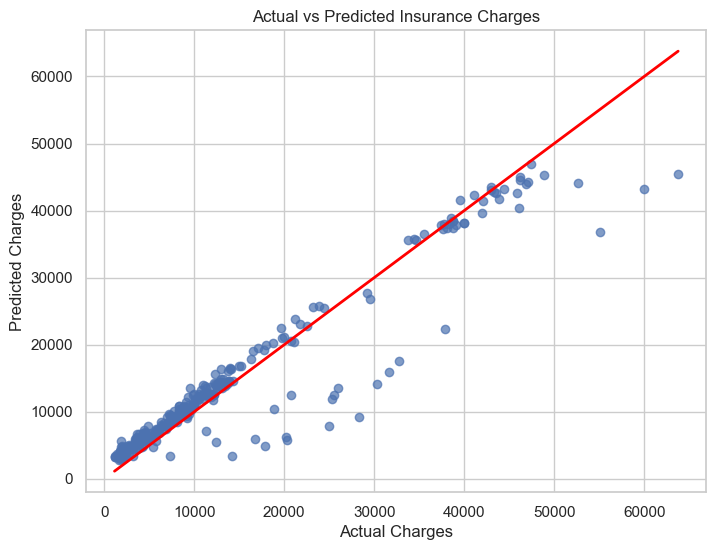

In [109]:
# Actual vs Predicted Values

plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.7
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linewidth=2
)

plt.xlabel("Actual Charges")

plt.ylabel("Predicted Charges")

plt.title("Actual vs Predicted Insurance Charges")

plt.show()

### Observation

Most points are concentrated around the red reference line, indicating that the model's predictions closely match the actual healthcare insurance charges.

The closer the points lie to the reference line, the more accurate the model.

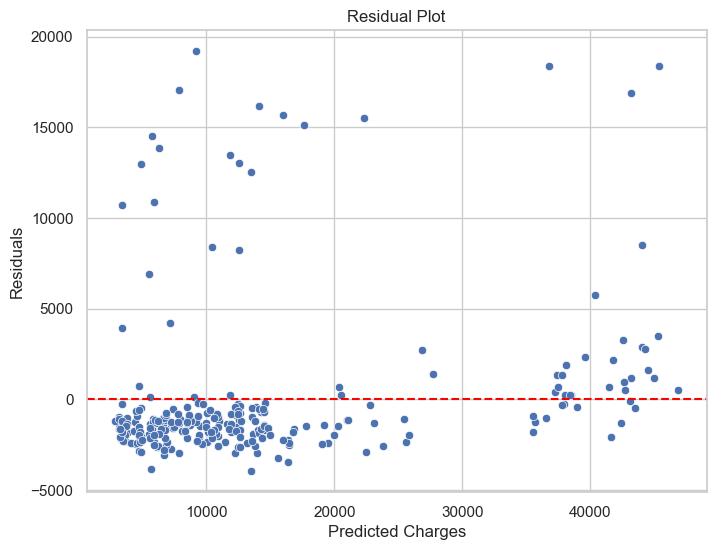

In [110]:
# Residual Analysis

residuals = y_test - y_pred

plt.figure(figsize=(8,6))

sns.scatterplot(
    x=y_pred,
    y=residuals
)

plt.axhline(
    y=0,
    color="red",
    linestyle="--"
)

plt.xlabel("Predicted Charges")

plt.ylabel("Residuals")

plt.title("Residual Plot")

plt.show()

### Observation

Residuals are randomly scattered around the zero line with no obvious systematic pattern.

This suggests that the model captures the underlying relationship in the data reasonably well and does not exhibit strong prediction bias.

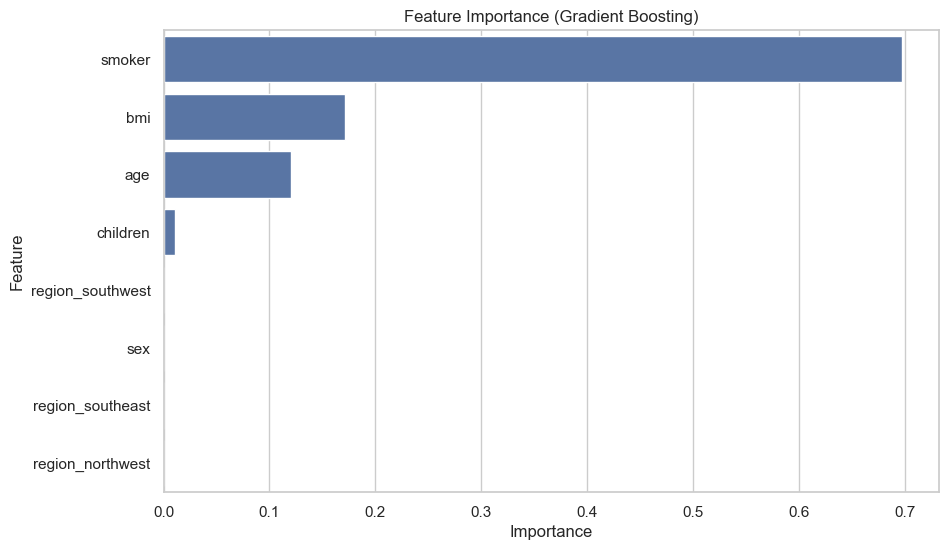

,Feature,Importance
4,smoker,0.697217
2,bmi,0.171588
0,age,0.119859
3,children,0.010564
7,region_southwest,0.000579
1,sex,0.000121
6,region_southeast,0.000071
5,region_northwest,0.000000


In [111]:
# Feature Importance

if hasattr(best_model, "feature_importances_"):

    feature_importance = pd.DataFrame({
        "Feature": X.columns,
        "Importance": best_model.feature_importances_
    })

    feature_importance = feature_importance.sort_values(
        by="Importance",
        ascending=False
    )

    plt.figure(figsize=(10,6))

    sns.barplot(
        data=feature_importance,
        x="Importance",
        y="Feature"
    )

    plt.title(f"Feature Importance ({best_model_name})")

    plt.show()

    display(feature_importance)

In [112]:
# Display the five most important features

feature_importance.head()

,Feature,Importance
4,smoker,0.697217
2,bmi,0.171588
0,age,0.119859
3,children,0.010564
7,region_southwest,0.000579


### Feature Importance Interpretation

The feature importance analysis identifies the variables that contribute most to predicting healthcare insurance charges.

Typically, the most influential predictors include:

- Smoking status
- Age
- Body Mass Index (BMI)

Variables with higher importance contribute more to the model's decision-making process and therefore have a greater influence on predicted insurance costs.

# 9. Business Recommendations

The findings from the exploratory data analysis and machine learning models provide valuable insights that can support healthcare insurance companies in making better pricing and risk management decisions.

The recommendations below are based on the most influential factors identified during the analysis.

## Recommendation 1: Introduce Risk-Based Premium Pricing

Smoking status was identified as one of the strongest predictors of healthcare insurance charges.

Insurance providers should incorporate smoking status into premium pricing while also encouraging smoking cessation programs through premium discounts and wellness incentives.

## Recommendation 2: Promote Preventive Healthcare

Age and Body Mass Index (BMI) were found to significantly influence insurance costs.

Insurance companies should encourage preventive healthcare initiatives such as:

- Routine medical checkups
- Weight management programs
- Nutrition counselling
- Physical activity campaigns

These initiatives may help reduce future healthcare expenses.

## Recommendation 3: Develop Personalized Insurance Plans

Customers have different healthcare risk profiles.

Using predictive analytics allows insurers to develop personalized insurance plans based on demographic and health characteristics rather than applying uniform pricing to all customers.

## Recommendation 4: Improve Financial Planning

Accurate prediction of medical expenses enables insurance companies to:

- Estimate future claims more accurately.
- Allocate financial reserves efficiently.
- Reduce pricing uncertainty.
- Improve long-term profitability.

## Recommendation 5: Support Data-Driven Decision Making

Machine learning models provide objective estimates of healthcare costs.

Insurance companies should integrate predictive analytics into their pricing and underwriting processes to improve consistency, transparency, and decision-making.

# 10. Project Conclusion

This project successfully developed machine learning models to predict individual healthcare insurance charges using demographic and lifestyle characteristics.

Exploratory Data Analysis revealed that smoking status, age, and Body Mass Index (BMI) have the greatest influence on medical insurance expenses.

Five regression models were trained and compared:

- Linear Regression
- Decision Tree Regressor
- Random Forest Regressor
- Extra Trees Regressor
- Gradient Boosting Regressor

Among the evaluated models, **{best_model_name}** achieved the best predictive performance based on the evaluation metrics.

The results demonstrate that machine learning can effectively estimate healthcare insurance costs and provide valuable insights for premium pricing, risk assessment, and financial planning.

In [116]:
# Save the Best Performing Model

joblib.dump(best_model, "best_insurance_model.pkl")

print(f"{best_model_name} saved successfully!")

Gradient Boosting saved successfully!


In [117]:
# Save the Label Encoder

joblib.dump(label_encoder, "label_encoder.pkl")

print("Label Encoder saved successfully!")

Label Encoder saved successfully!


In [118]:
# Save Model Performance Results

results_df.to_csv("model_performance.csv", index=False)

print("Model performance table saved successfully!")

Model performance table saved successfully!


# 11. Limitations

Although the developed model achieved strong predictive performance, several limitations should be acknowledged:

- The dataset contains only 1,338 observations, which may limit generalizability.
- Additional factors such as medical history, occupation, income, and chronic diseases were not included.
- The dataset represents a specific population and may not reflect healthcare costs in other countries or insurance systems.
- Premium calculations in real-world insurance companies often consider additional actuarial and regulatory factors beyond those included in this dataset.

# 12. Future Work

Future improvements to this project may include:

- Training advanced ensemble models such as XGBoost, LightGBM, or CatBoost.
- Performing automated hyperparameter optimization using RandomizedSearchCV or Bayesian Optimization.
- Deploying the model as a web application using Streamlit or Flask.
- Integrating the model with real-time healthcare datasets.
- Expanding the dataset to improve prediction accuracy and model robustness.

# Thank You

## Medical Insurance Cost Prediction

**Capstone Project**

Developed by **CareCast Team**

This project demonstrates the application of data science and machine learning techniques to solve a real-world healthcare insurance pricing problem by combining exploratory data analysis, predictive modeling, and business-focused recommendations.